# Exercise Recognition Dataset Exploration

This notebook explores the Resistive Band dataset for 3D-CNN action recognition.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

In [2]:
# Set up paths
BASE_DIR = Path("..").resolve()
DATA_DIR = BASE_DIR / "data"

SKELETON_DIR = DATA_DIR / "dataset" / "skeleton" / "yolo_pose_csv"
LABEL_DIR = DATA_DIR / "label"

## 1. List Available Files

In [3]:
# Get list of skeleton and label files
skeleton_files = sorted([f for f in os.listdir(SKELETON_DIR) if f.endswith('.csv')])
label_files = sorted([f for f in os.listdir(LABEL_DIR) if f.endswith('.csv')])

print(f"Number of skeleton files: {len(skeleton_files)}")
print(f"Number of label files: {len(label_files)}")

# Find matching files (files that exist in both directories)
skeleton_names = {f.replace('.csv', '') for f in skeleton_files}
label_names = {f.replace('.csv', '') for f in label_files}
matching_files = skeleton_names.intersection(label_names)

print(f"\nMatching files (in both skeleton and label): {len(matching_files)}")
print(f"Files only in skeleton: {len(skeleton_names - label_names)}")
print(f"Files only in label: {len(label_names - skeleton_names)}")

Number of skeleton files: 60
Number of label files: 60

Matching files (in both skeleton and label): 59
Files only in skeleton: 1
Files only in label: 1


## 2. Explore Skeleton Data Structure

In [4]:
# Load a sample skeleton file
sample_skeleton_file = sorted(matching_files)[0] + '.csv'
skeleton_df = pd.read_csv(SKELETON_DIR / sample_skeleton_file)

print(f"Sample skeleton file: {sample_skeleton_file}")
print(f"\nDataFrame shape: {skeleton_df.shape}")
print(f"\nColumn names: {skeleton_df.columns.tolist()}")
print(f"\nData types:\n{skeleton_df.dtypes}")
print("\nFirst 20 rows:")
skeleton_df.head(20)

Sample skeleton file: 001_d26arrd1.csv

DataFrame shape: (146115, 5)

Column names: ['frame_number', 'landmark', 'x', 'y', 'z']

Data types:
frame_number      int64
landmark         object
x               float64
y               float64
z               float64
dtype: object

First 20 rows:


,frame_number,landmark,x,y,z
0,1,NOSE,0.2579,0.2531,0.0
1,1,LEFT_EYE,0.2688,0.2427,0.0
2,1,RIGHT_EYE,0.2482,0.2419,0.0
3,1,LEFT_EAR,0.2823,0.2579,0.0
4,1,RIGHT_EAR,0.2350,0.2565,0.0
5,1,LEFT_SHOULDER,0.3008,0.3348,0.0
6,1,RIGHT_SHOULDER,0.2116,0.3328,0.0
7,1,LEFT_ELBOW,0.3270,0.3849,0.0
8,1,RIGHT_ELBOW,0.1710,0.3822,0.0
9,1,LEFT_WRIST,0.3289,0.3865,0.0


In [5]:
# Get unique landmarks (body keypoints)
landmarks = skeleton_df['landmark'].unique()
print(f"Number of unique landmarks: {len(landmarks)}")
print("\nLandmarks (YOLO Pose keypoints):")
for i, landmark in enumerate(landmarks):
    print(f"  {i}: {landmark}")

# Number of frames in this file
num_frames = skeleton_df['frame_number'].nunique()
print(f"\nNumber of frames: {num_frames}")
print(f"Rows per frame: {len(skeleton_df) / num_frames}")

Number of unique landmarks: 17

Landmarks (YOLO Pose keypoints):
  0: NOSE
  1: LEFT_EYE
  2: RIGHT_EYE
  3: LEFT_EAR
  4: RIGHT_EAR
  5: LEFT_SHOULDER
  6: RIGHT_SHOULDER
  7: LEFT_ELBOW
  8: RIGHT_ELBOW
  9: LEFT_WRIST
  10: RIGHT_WRIST
  11: LEFT_HIP
  12: RIGHT_HIP
  13: LEFT_KNEE
  14: RIGHT_KNEE
  15: LEFT_ANKLE
  16: RIGHT_ANKLE

Number of frames: 8595
Rows per frame: 17.0


In [6]:
# Check coordinate ranges
print("Coordinate statistics:")
print(f"\nX coordinate range: [{skeleton_df['x'].min():.4f}, {skeleton_df['x'].max():.4f}]")
print(f"Y coordinate range: [{skeleton_df['y'].min():.4f}, {skeleton_df['y'].max():.4f}]")
print(f"Z coordinate range: [{skeleton_df['z'].min():.4f}, {skeleton_df['z'].max():.4f}]")

print("\nCoordinate statistics summary:")
skeleton_df[['x', 'y', 'z']].describe()

Coordinate statistics:

X coordinate range: [0.0000, 0.4479]
Y coordinate range: [0.0000, 0.8344]
Z coordinate range: [0.0000, 0.0000]

Coordinate statistics summary:


,x,y,z
count,146115.000000,146115.000000,146115.0
mean,0.256909,0.432587,0.0
std,0.051583,0.198024,0.0
min,0.000000,0.000000,0.0
25%,0.229500,0.254000,0.0
50%,0.261700,0.350600,0.0
75%,0.283600,0.518300,0.0
max,0.447900,0.834400,0.0


## 3. Explore Label Data Structure

In [7]:
# Load the corresponding label file
sample_label_file = sample_skeleton_file
label_df = pd.read_csv(LABEL_DIR / sample_label_file, header=None, names=['frame', 'col1', 'label'])

print(f"Sample label file: {sample_label_file}")
print(f"\nDataFrame shape: {label_df.shape}")
print(f"\nColumn names: {label_df.columns.tolist()}")
print("\nFirst 20 rows:")
label_df.head(20)

Sample label file: 001_d26arrd1.csv

DataFrame shape: (8595, 3)

Column names: ['frame', 'col1', 'label']

First 20 rows:


,frame,col1,label
0,1,-1,-1
1,2,-1,-1
2,3,-1,-1
3,4,-1,-1
4,5,-1,-1
5,6,-1,-1
6,7,-1,-1
7,8,-1,-1
8,9,-1,-1
9,10,-1,-1


In [8]:
# Analyze unique labels in this file
unique_labels = label_df['label'].unique()
print(f"Unique labels in this file: {sorted(unique_labels)}")
print("\nLabel distribution:")
label_counts = label_df['label'].value_counts().sort_index()
for label, count in label_counts.items():
    print(f"  Label {label}: {count} frames ({100*count/len(label_df):.1f}%)")

Unique labels in this file: [np.int64(-1), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]

Label distribution:
  Label -1: 2319 frames (27.0%)
  Label 1: 2128 frames (24.8%)
  Label 2: 270 frames (3.1%)
  Label 3: 370 frames (4.3%)
  Label 4: 309 frames (3.6%)
  Label 5: 384 frames (4.5%)
  Label 7: 234 frames (2.7%)
  Label 8: 300 frames (3.5%)
  Label 9: 288 frames (3.4%)
  Label 10: 269 frames (3.1%)
  Label 11: 272 frames (3.2%)
  Label 12: 258 frames (3.0%)
  Label 13: 304 frames (3.5%)
  Label 14: 282 frames (3.3%)
  Label 15: 329 frames (3.8%)
  Label 16: 279 frames (3.2%)


## 4. Analyze All Files - Label Distribution

In [9]:
# Collect label statistics from all files
all_labels = []
file_stats = []

for file_name in sorted(matching_files):
    label_path = LABEL_DIR / f"{file_name}.csv"
    df = pd.read_csv(label_path, header=None, names=['frame', 'col1', 'label'])

    all_labels.extend(df['label'].tolist())

    # Statistics per file
    unique_labels = df['label'].unique()
    exercise_labels = [l for l in unique_labels if l != -1]
    file_stats.append({
        'file': file_name,
        'total_frames': len(df),
        'unique_labels': len(unique_labels),
        'exercise_types': exercise_labels
    })

# Overall label distribution
label_counter = Counter(all_labels)
print("Overall label distribution across all files:")
print(f"{'Label':<10} {'Count':<10} {'Percentage':<10}")
print("-" * 30)
for label in sorted(label_counter.keys()):
    count = label_counter[label]
    pct = 100 * count / len(all_labels)
    print(f"{label:<10} {count:<10} {pct:.2f}%")

Overall label distribution across all files:
Label      Count      Percentage
------------------------------
-1         272016     40.88%
1          120152     18.06%
2          19117      2.87%
3          18348      2.76%
4          17207      2.59%
5          19435      2.92%
6          16817      2.53%
7          17978      2.70%
8          19731      2.97%
9          17102      2.57%
10         17140      2.58%
11         16578      2.49%
12         18276      2.75%
13         20092      3.02%
14         18083      2.72%
15         19579      2.94%
16         17725      2.66%


In [10]:
# Create exercise label mapping (excluding -1 which is "no activity")
exercise_labels = [l for l in sorted(label_counter.keys()) if l != -1]
exercise_names = {
    -1: "No Activity",
    1: "Exercise 1",
    2: "Exercise 2",
    3: "Exercise 3",
    4: "Exercise 4",
    5: "Exercise 5",
    6: "Exercise 6",
    7: "Exercise 7",
    8: "Exercise 8",
    9: "Exercise 9",
    10: "Exercise 10",
    11: "Exercise 11",
    12: "Exercise 12",
    13: "Exercise 13",
    14: "Exercise 14",
    15: "Exercise 15",
    16: "Exercise 16"
}

print(f"\nNumber of exercise classes (excluding 'no activity'): {len(exercise_labels)}")
print(f"Exercise labels found: {exercise_labels}")


Number of exercise classes (excluding 'no activity'): 16
Exercise labels found: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


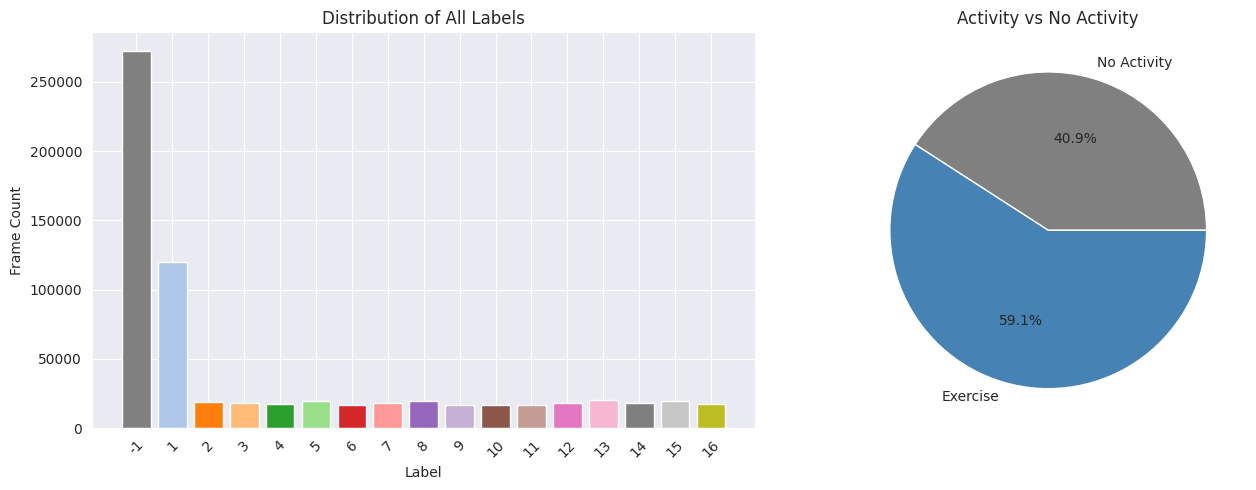

In [11]:
# Visualize label distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of all labels
labels = sorted(label_counter.keys())
counts = [label_counter[l] for l in labels]
colors = ['gray' if l == -1 else plt.cm.tab20(i % 20) for i, l in enumerate(labels)] # type: ignore

axes[0].bar([str(label) for label in labels], counts, color=colors)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Frame Count')
axes[0].set_title('Distribution of All Labels')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart of exercise vs no-activity
no_activity_count = label_counter.get(-1, 0)
activity_count = sum(c for label, c in label_counter.items() if label != -1)
axes[1].pie([no_activity_count, activity_count],
            labels=['No Activity', 'Exercise'],
            autopct='%1.1f%%',
            colors=['gray', 'steelblue'])
axes[1].set_title('Activity vs No Activity')

plt.tight_layout()
plt.show()

## 5. File-level Statistics

Total files: 59

Frame count statistics:
count       59.000000
mean     11277.559322
std       1663.463486
min       8124.000000
25%      10287.500000
50%      11109.000000
75%      12191.500000
max      14690.000000
Name: total_frames, dtype: float64


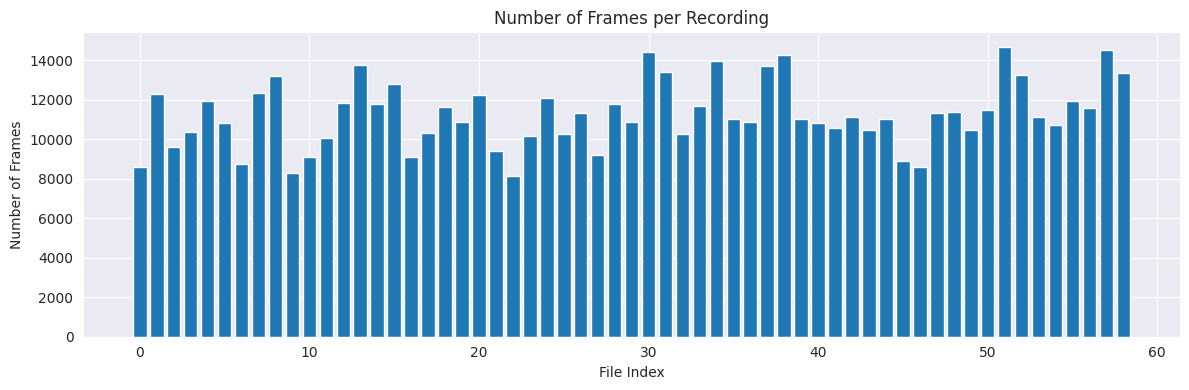

In [12]:
# Create DataFrame with file statistics
file_stats_df = pd.DataFrame(file_stats)
print(f"Total files: {len(file_stats_df)}")
print("\nFrame count statistics:")
print(file_stats_df['total_frames'].describe())

# Plot frame count distribution
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(file_stats_df)), file_stats_df['total_frames'])
ax.set_xlabel('File Index')
ax.set_ylabel('Number of Frames')
ax.set_title('Number of Frames per Recording')
plt.tight_layout()
plt.show()

## 6. Visualize Skeleton Data

In [13]:
# Define skeleton connections (YOLO Pose format)
SKELETON_CONNECTIONS = [
    ('NOSE', 'LEFT_EYE'), ('NOSE', 'RIGHT_EYE'),
    ('LEFT_EYE', 'LEFT_EAR'), ('RIGHT_EYE', 'RIGHT_EAR'),
    ('LEFT_SHOULDER', 'RIGHT_SHOULDER'),
    ('LEFT_SHOULDER', 'LEFT_ELBOW'), ('RIGHT_SHOULDER', 'RIGHT_ELBOW'),
    ('LEFT_ELBOW', 'LEFT_WRIST'), ('RIGHT_ELBOW', 'RIGHT_WRIST'),
    ('LEFT_SHOULDER', 'LEFT_HIP'), ('RIGHT_SHOULDER', 'RIGHT_HIP'),
    ('LEFT_HIP', 'RIGHT_HIP'),
    ('LEFT_HIP', 'LEFT_KNEE'), ('RIGHT_HIP', 'RIGHT_KNEE'),
    ('LEFT_KNEE', 'LEFT_ANKLE'), ('RIGHT_KNEE', 'RIGHT_ANKLE')
]

def plot_skeleton_frame(skeleton_df, frame_num, ax, title=''):
    """Plot skeleton for a specific frame."""
    frame_data = skeleton_df[skeleton_df['frame_number'] == frame_num]

    # Create landmark dictionary
    landmarks = {}
    for _, row in frame_data.iterrows():
        landmarks[row['landmark']] = (row['x'], row['y'])

    # Plot connections
    for start, end in SKELETON_CONNECTIONS:
        if start in landmarks and end in landmarks:
            x_vals = [landmarks[start][0], landmarks[end][0]]
            y_vals = [landmarks[start][1], landmarks[end][1]]
            ax.plot(x_vals, y_vals, 'b-', linewidth=2, alpha=0.7)

    # Plot keypoints
    for _, (x, y) in landmarks.items():
        ax.scatter(x, y, c='red', s=50, zorder=5)

    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)  # Invert Y axis (image coordinates)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

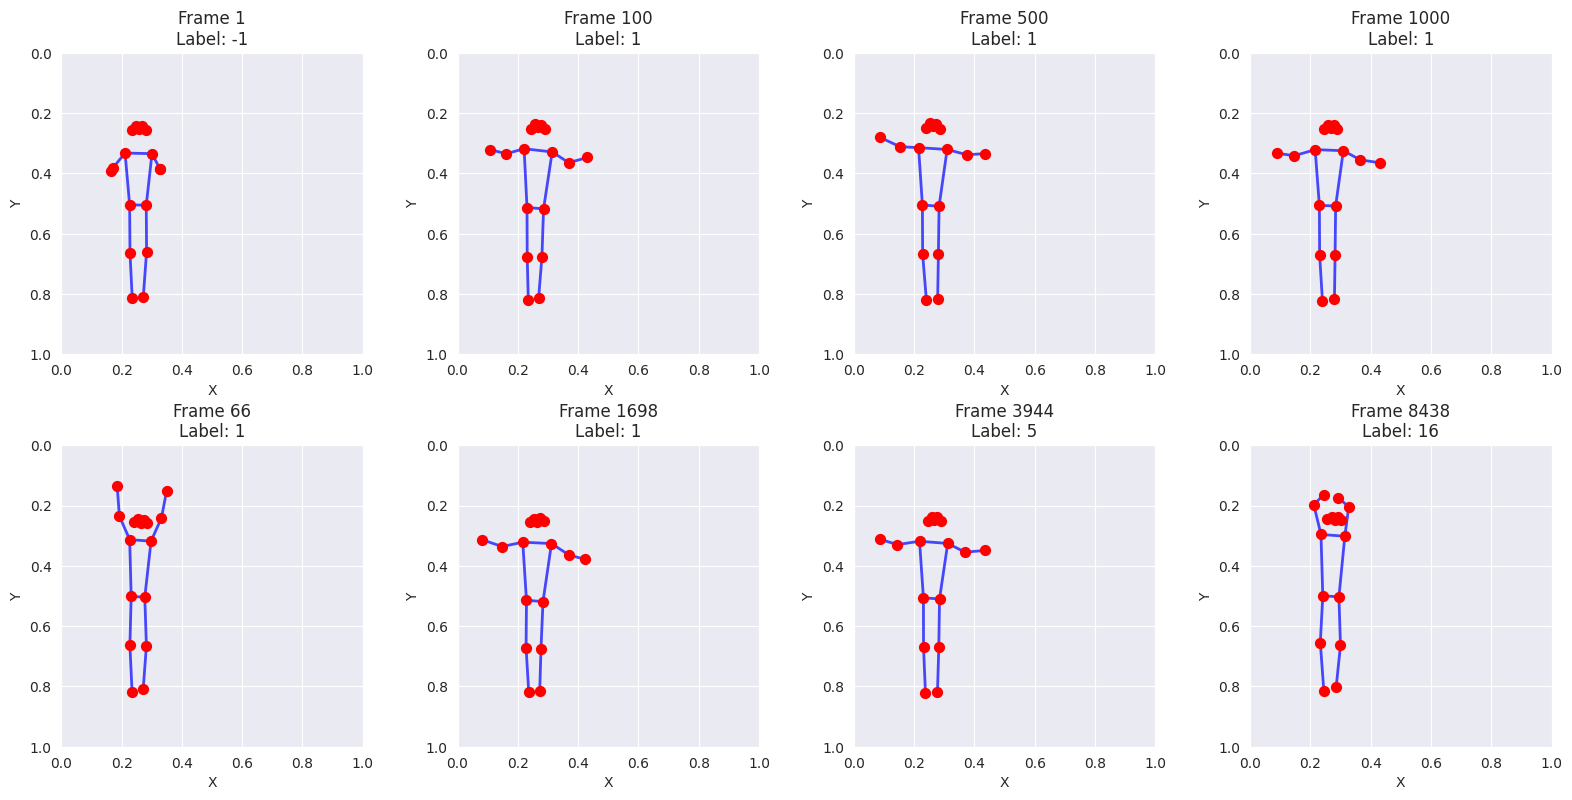

In [14]:
# Plot skeleton at different frames
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Get frames with exercise activity
exercise_frames = label_df[label_df['label'] != -1]['frame'].values

# Sample frames
sample_frames = [1, 100, 500, 1000]
if len(exercise_frames) > 0:
    sample_frames.extend([exercise_frames[0], exercise_frames[len(exercise_frames)//4],
                          exercise_frames[len(exercise_frames)//2], exercise_frames[-100]])

for idx, frame in enumerate(sample_frames[:8]):
    label = label_df[label_df['frame'] == frame]['label'].values[0] if frame <= len(label_df) else -1
    plot_skeleton_frame(skeleton_df, frame, axes[idx],
                       f'Frame {frame}\nLabel: {label}')

plt.tight_layout()
plt.show()

## 7. Temporal Analysis - Label Changes Over Time

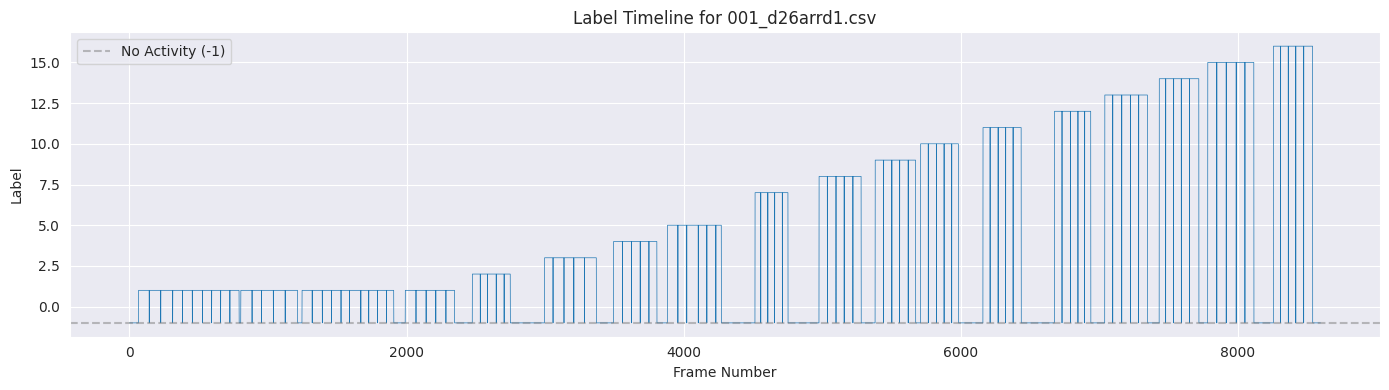


Number of segments: 203

Segment duration statistics:
count    203.000000
mean      42.339901
std       44.638678
min        1.000000
25%        1.000000
50%       53.000000
75%       64.000000
max      247.000000
Name: duration, dtype: float64


In [15]:
# Plot label over time for a sample file
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(label_df['frame'], label_df['label'], linewidth=0.5)
ax.set_xlabel('Frame Number')
ax.set_ylabel('Label')
ax.set_title(f'Label Timeline for {sample_skeleton_file}')
ax.axhline(y=-1, color='gray', linestyle='--', alpha=0.5, label='No Activity (-1)')
ax.legend()
plt.tight_layout()
plt.show()

# Count exercise segments (continuous sequences with same label)
segments = []
current_label = label_df['label'].iloc[0]
segment_start = 0

for idx, row in label_df.iterrows():
    if row['label'] != current_label:
        segments.append({
            'label': current_label,
            'start': segment_start,
            'end': idx - 1, # type: ignore
            'duration': idx - segment_start # type: ignore
        })
        current_label = row['label']
        segment_start = idx

# Add last segment
segments.append({
    'label': current_label,
    'start': segment_start,
    'end': len(label_df) - 1,
    'duration': len(label_df) - segment_start # type: ignore
})

segments_df = pd.DataFrame(segments)
print(f"\nNumber of segments: {len(segments_df)}")
print("\nSegment duration statistics:")
print(segments_df['duration'].describe())

## 8. Data Transformation for 3D-CNN

The 3D-CNN expects input of shape `(batch, channels, depth, height, width)` or in our case `(batch, temporal_frames, num_keypoints, coordinates)`.

We'll convert the skeleton data to a format suitable for 3D convolutions.

In [16]:
def skeleton_to_array(skeleton_df):
    """Convert skeleton DataFrame to numpy array."""
    # Get unique landmarks in order
    landmarks_order = skeleton_df[skeleton_df['frame_number'] == 1]['landmark'].tolist()
    num_keypoints = len(landmarks_order)

    # Get frame range
    frames = skeleton_df['frame_number'].unique()
    num_frames = len(frames)

    # Initialize array
    skeleton_array = np.zeros((num_frames, num_keypoints, 3))

    for frame_idx, frame_num in enumerate(sorted(frames)):
        frame_data = skeleton_df[skeleton_df['frame_number'] == frame_num]
        for kp_idx, landmark in enumerate(landmarks_order):
            kp_data = frame_data[frame_data['landmark'] == landmark]
            if len(kp_data) > 0:
                skeleton_array[frame_idx, kp_idx, 0] = kp_data['x'].values[0]
                skeleton_array[frame_idx, kp_idx, 1] = kp_data['y'].values[0]
                skeleton_array[frame_idx, kp_idx, 2] = kp_data['z'].values[0]

    return skeleton_array, landmarks_order

# Convert sample file
skeleton_array, landmark_names = skeleton_to_array(skeleton_df)
print(f"Skeleton array shape: {skeleton_array.shape}")
print(f"  - Dimension 0: {skeleton_array.shape[0]} frames")
print(f"  - Dimension 1: {skeleton_array.shape[1]} keypoints")
print(f"  - Dimension 2: {skeleton_array.shape[2]} coordinates (x, y, z)")
print(f"\nKeypoint order: {landmark_names}")

Skeleton array shape: (8595, 17, 3)
  - Dimension 0: 8595 frames
  - Dimension 1: 17 keypoints
  - Dimension 2: 3 coordinates (x, y, z)

Keypoint order: ['NOSE', 'LEFT_EYE', 'RIGHT_EYE', 'LEFT_EAR', 'RIGHT_EAR', 'LEFT_SHOULDER', 'RIGHT_SHOULDER', 'LEFT_ELBOW', 'RIGHT_ELBOW', 'LEFT_WRIST', 'RIGHT_WRIST', 'LEFT_HIP', 'RIGHT_HIP', 'LEFT_KNEE', 'RIGHT_KNEE', 'LEFT_ANKLE', 'RIGHT_ANKLE']


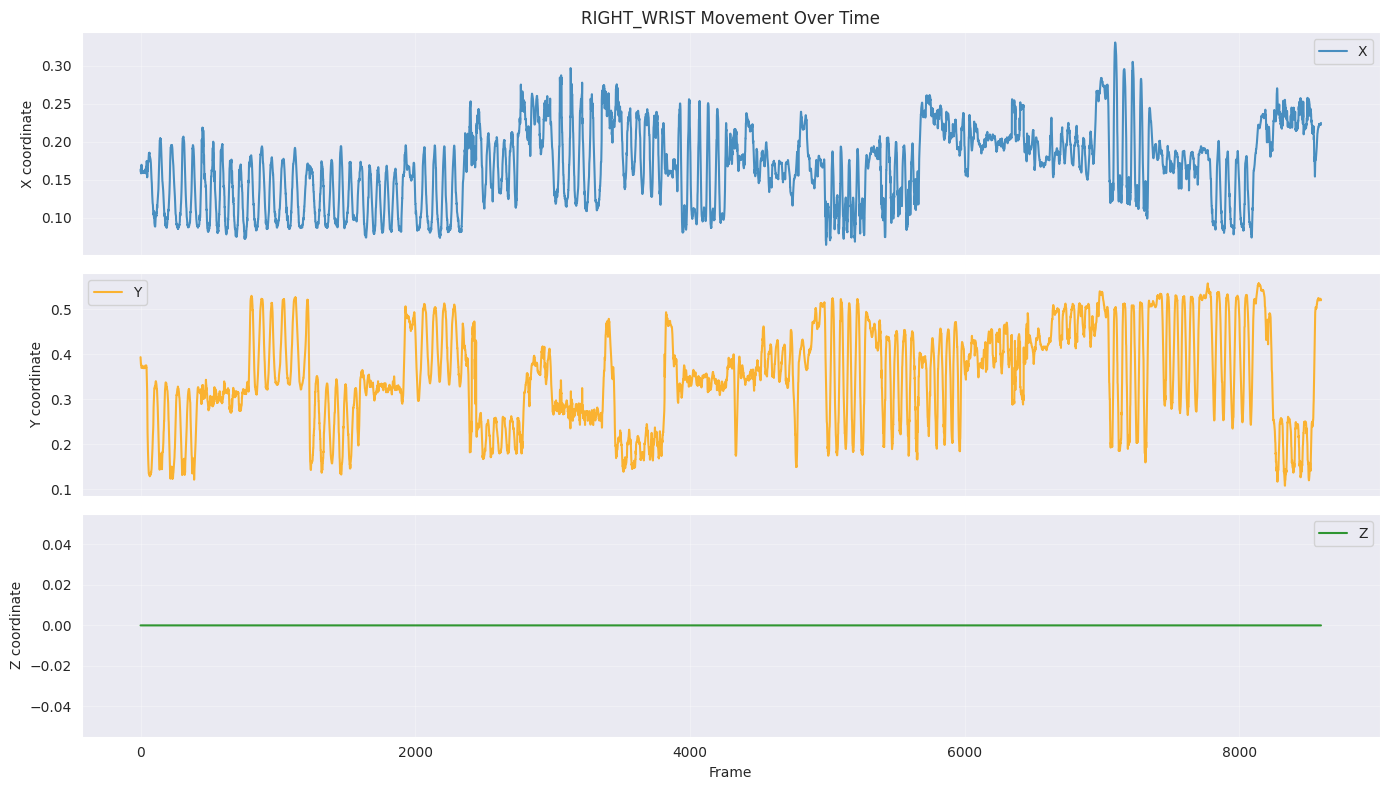

In [17]:
# Visualize keypoint movement over time
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# Select a keypoint to visualize (e.g., right wrist)
kp_idx = landmark_names.index('RIGHT_WRIST')
kp_name = landmark_names[kp_idx]

# Plot x, y, z coordinates over time
axes[0].plot(skeleton_array[:, kp_idx, 0], label='X', alpha=0.8)
axes[0].set_ylabel('X coordinate')
axes[0].set_title(f'{kp_name} Movement Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(skeleton_array[:, kp_idx, 1], label='Y', color='orange', alpha=0.8)
axes[1].set_ylabel('Y coordinate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(skeleton_array[:, kp_idx, 2], label='Z', color='green', alpha=0.8)
axes[2].set_ylabel('Z coordinate')
axes[2].set_xlabel('Frame')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()